## Calculate the MSA mean monthly 2001-2021
1. PRISM Data (tdmean, tmean, ppt)
2. SIF

In [1]:

import xarray as xr
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as crs
import cartopy.feature as cfeature
import netCDF4 as nc
import rioxarray as rxr
import numpy as np
import rasterio
import constants

In [2]:
# read shapefile and unit crs
msa_gdf_crsaea = gpd.read_file(constants.MSA_FILE)
msa_gdf_crs4269 = msa_gdf_crsaea.to_crs(epsg=4269) #prism metadata: North American Datum of 1983
msa_gdf_crs4326 = msa_gdf_crsaea.to_crs(epsg=4326) #sif is in 4326

### calculate PRISM Meteorologial MSA mean

In [3]:
TMEAN_FILE = '../data/PRISM Meteorologial Variables/tmean_monthly_01_1980_12_2021.mat'
import h5py

# Open the .mat file
with h5py.File(TMEAN_FILE, 'r') as mat_file:
    # Print the keys to see what datasets are available
    print(mat_file.keys())
    
    # Suppose the data is in 'raster_data'
    raster_data = mat_file['data']
    
    # Check the shape of the data
    print(raster_data.shape)

<KeysViewHDF5 ['data']>
(504, 1405, 621)


In [4]:
import h5py
import numpy as np

TMEAN_FILE = '../data/PRISM Meteorologial Variables/tmean_monthly_01_1980_12_2021.mat'
TDMEAN_FILE = '../data/PRISM Meteorologial Variables/tdmean_monthly_01_1980_12_2021.mat'
PPT_FILE = '../data/PRISM Meteorologial Variables/ppt_monthly_01_1980_12_2021.mat'
def load_h5py_file(file_path: str) -> np.ndarray:
    with h5py.File(file_path, 'r') as f:
        data = f['data'] # have checked that this is the correct key
        raster_data = np.array(data) # have checked the order is: (time, lon, lat)
        raster_data = np.transpose(raster_data, (0, 2, 1)) # transpose to (time, lat, lon) for imshow and rasterio 
    return raster_data 

tmean_raster_data = load_h5py_file(TMEAN_FILE)
tdmean_raster_data = load_h5py_file(TDMEAN_FILE)
ppt_raster_data = load_h5py_file(PPT_FILE)

In [5]:
# Calculate transform for .mat data  (boundary, resolution information retrieved from PRISM metadata)
xmin, ymin, xmax, ymax = -125.0208333, 24.0625000, -66.4791667, 49.9375000

# Compute resolution
res_x = 0.04166667  # Longitude resolution
res_y = 0.04166667  # Latitude resolution

prism_transform = rasterio.transform.from_origin(xmin, ymax, res_x, res_y)
print(prism_transform)


| 0.04, 0.00,-125.02|
| 0.00,-0.04, 49.94|
| 0.00, 0.00, 1.00|


c:\Users\qifanw\Documents\code\.venv\Lib\site-packages\matplotlib\image.py:492: RuntimeWarning: invalid value encountered in subtract
  A_scaled -= a_min


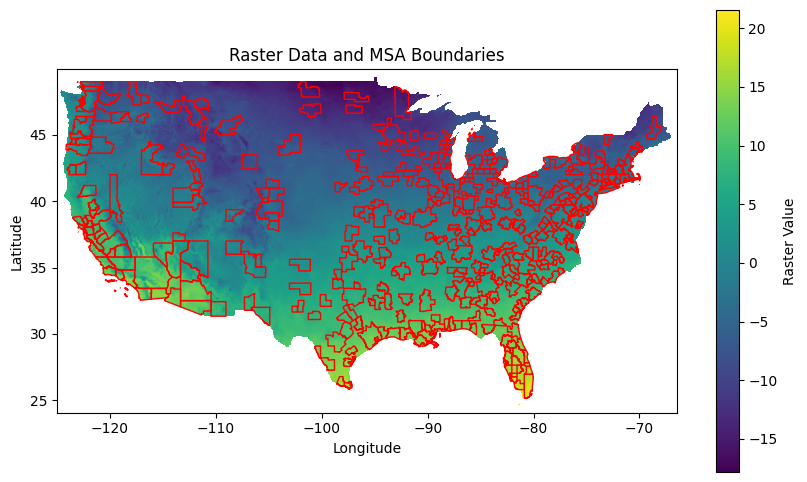

In [6]:
# Display prism and shapefile on the same map

import matplotlib.pyplot as plt
from rasterio.plot import show
import numpy as np

data_ym = tmean_raster_data[0]  # Get data for January 1980 for test

transform = prism_transform  # Get transformation for plotting
extent = [prism_transform[2], prism_transform[2] + prism_transform[0] * data_ym.shape[1],
        prism_transform[5] + prism_transform[4] * data_ym.shape[0], prism_transform[5]]  # Raster extent

# Plot the raster and MSA shapefile
fig, ax = plt.subplots(figsize=(10, 6))

# Plot raster
im = ax.imshow(data_ym, extent=extent, cmap="viridis", origin="upper")  # Adjust color if needed
plt.colorbar(im, ax=ax, label="Raster Value")  # Add color legend

# Overlay MSA shapefile
msa_gdf_crs4269.boundary.plot(ax=ax, color="red", linewidth=1)  # Plot MSA boundaries

# Customize plot
ax.set_title("Raster Data and MSA Boundaries")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()


In [7]:
from utils import get_masked_raster
import pandas as pd

In [ ]:
# get slice of data from 2001-01 to 2015-12
start_year = 2001
end_year = 2021

# msa_name = 'Houston-Pasadena-The Woodlands, TX Metro Area'
# selected_msa = msa_gdf_crs4269[msa_gdf_crs4269['NAMELSAD'] == msa_name]

msa_means = {'tmean': {}, 'tdmean': {}, 'ppt': {}}

from tqdm import tqdm  

# Iterate over each MSA
for idx, msa in tqdm(msa_gdf_crs4269.iterrows(), total=len(msa_gdf_crs4269), desc="Processing MSAs"):
    msa_name = msa['NAMELSAD']
    msa_gdf = msa_gdf_crs4269[msa_gdf_crs4269["NAMELSAD"] == msa_name]  # Extract single MSA as GeoDataFrame
    for cat in ['tmean', 'tdmean', 'ppt']:
        msa_means[cat][msa_name] = {}

    for i in range((start_year - 1980) * 12, (end_year - 1980 + 1) * 12):
        year = i // 12 + 1980
        month = i % 12 + 1
        for cat, raster_data in {'tmean':tmean_raster_data, 'tdmean':tdmean_raster_data, 'ppt':ppt_raster_data}.items():
            data_ym = raster_data[i, :, :]

            prism_selected_msa = get_masked_raster(msa_gdf, data_ym, prism_transform)
            prism_selected_msa_mean = np.nanmean(prism_selected_msa)

            msa_means[cat][msa_name][f"{year:04d}{month:02d}"] = prism_selected_msa_mean

# msa_df = pd.DataFrame.from_dict(msa_means, orient='index')



Processing MSAs: 100%|██████████| 383/383 [43:00<00:00,  6.74s/it] 


In [9]:
for cat in ['tmean', 'tdmean', 'ppt']:
    cat_msa_mean = pd.DataFrame.from_dict(msa_means[cat], orient='index')
    cat_msa_mean.to_csv(f'../data/intermedia/prism_msa_mean/{cat}_msa_mean_{start_year}-{end_year}.csv')

### calcumate SIF msa mean

In [ ]:


# # Decompress the SIF files
# import gzip
# import shutil
# for year in range(start_year, end_year+1):
#     for month in range(1, 13):
#         SIF_file = f'../gis/SIF/2016-2021/GOSIF_{year:04d}.M{month:02d}.tif.gz'
#         decompressed_file = SIF_file.replace('.gz', '')
#         with gzip.open(SIF_file, 'rb') as f_in:
#             with open(decompressed_file, 'wb') as f_out:
#                 shutil.copyfileobj(f_in, f_out)

In [3]:
start_year = 2001
end_year = 2021

In [4]:
import geopandas as gpd
import numpy as np
import rioxarray
import pandas as pd
import rasterio.features
from utils import get_masked_raster


# Initialize dictionary to store results
sif_msa_mean_dict = {msa_name: [] for msa_name in msa_gdf_crs4326['NAMELSAD']}

# Process each time step
for year in range(start_year, end_year+1):
    for month in range(1, 13):
        year_month = f'{year:04d}{month:02d}'
        print(f"Processing {year_month}")
        SIF_file = f'../gis/SIF/GOSIF_{year:04d}.M{month:02d}.tif'
        
        raster_ds = rioxarray.open_rasterio(SIF_file)
        raster_data = raster_ds.values[0]
        
        # Replace nodata (fill value) with NaN (Fill values: 32767 (water bodies) and 32766 (lands under snow/ice throughout the year)

        raster_data = np.where((raster_data == 32767) | (raster_data == 32766), np.nan, raster_data)
        
        
        for _, row in msa_gdf_crs4326.iterrows():
            row_gdf = msa_gdf_crs4326.loc[[row.name]] # Create a one-row GeoDataFrame instead of filtering
            masked_raster = get_masked_raster(row_gdf, raster_data, raster_ds.rio.transform())
            mean_value = np.nanmean(masked_raster)
            SIF_SCALE_FACTOR = 0.0001 # Scale factor for SIF data from GOSIF https://data.globalecology.unh.edu/data/GOSIF_v2/Fair_Data_Use_Policy_and_Readme_GOSIF_v2.pdf
            sif_msa_mean_dict[row['NAMELSAD']].append(mean_value * SIF_SCALE_FACTOR)


# Convert dictionary to DataFrame
sif_df = pd.DataFrame.from_dict(sif_msa_mean_dict, orient='index', columns=[f'{year:04d}{month:02d}' for year in range(start_year,end_year+1) for month in range(1,13)])
# Save to CSV
sif_df.to_csv(f"../data/intermedia/green_indices_msa_mean/sif_msa_mean_{start_year}-{end_year}.csv")

Processing 200101
Processing 200102
Processing 200103
Processing 200104
Processing 200105
Processing 200106
Processing 200107
Processing 200108
Processing 200109
Processing 200110
Processing 200111
Processing 200112
Processing 200201
Processing 200202
Processing 200203
Processing 200204
Processing 200205
Processing 200206
Processing 200207
Processing 200208
Processing 200209
Processing 200210
Processing 200211
Processing 200212
Processing 200301
Processing 200302
Processing 200303
Processing 200304
Processing 200305
Processing 200306
Processing 200307
Processing 200308
Processing 200309
Processing 200310
Processing 200311
Processing 200312
Processing 200401
Processing 200402
Processing 200403
Processing 200404
Processing 200405
Processing 200406
Processing 200407
Processing 200408
Processing 200409
Processing 200410
Processing 200411
Processing 200412
Processing 200501
Processing 200502
Processing 200503
Processing 200504
Processing 200505
Processing 200506
Processing 200507
Processing

In [16]:
sif_df

,201601,201602,201603,201604,201605,201606,201607,201608,201609,201610,...,202103,202104,202105,202106,202107,202108,202109,202110,202111,202112
"Sioux Falls, SD-MN Metro Area",18.074074,-30.358974,59.111111,396.743590,1006.122507,2392.065527,4554.863248,4913.863248,2420.031339,532.210826,...,29.484419,265.620397,803.246459,2148.161473,4239.830028,4118.014164,1899.424929,499.600567,163.954674,34.348442
"Wichita Falls, TX Metro Area",335.858736,594.468401,1197.531599,1781.959108,2118.371747,2094.847584,1985.185874,1524.148699,1501.040892,1284.055762,...,858.155235,1470.075812,2077.718412,2261.133574,2354.220217,1939.397112,1275.462094,750.433213,503.292419,366.801444
"College Station-Bryan, TX Metro Area",717.425234,1011.602804,1886.070093,2711.579439,2901.350467,3245.649533,2925.705607,2579.668224,2643.261682,1736.948598,...,1365.995169,2483.280193,3032.062802,3281.772947,3341.840580,2914.154589,1967.951691,1688.816425,1225.299517,971.748792
"Grand Forks, ND-MN Metro Area",36.767442,-17.609302,-10.123256,87.404651,606.874419,2971.209302,4023.039535,3276.627907,1418.527907,363.497674,...,13.658140,50.318605,530.844186,2062.339535,2854.067442,2208.169767,1170.462791,446.197674,66.439535,45.579070
"Sebring, FL Metro Area",1213.434343,1304.424242,1699.070707,2328.131313,2617.020202,2793.414141,2895.494949,2840.969697,2652.878788,2224.454545,...,1884.171429,2388.819048,2742.352381,2746.447619,3030.647619,2964.628571,2683.304762,2238.323810,1655.828571,1517.771429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Baltimore-Columbia-Towson, MD Metro Area",150.105072,160.909420,717.623188,1557.391304,2724.992754,3870.586957,3850.449275,3660.829710,2686.141304,1405.724638,...,546.338462,1737.346154,3356.784615,3798.973077,3882.907692,3468.276923,2786.300000,1633.753846,596.253846,316.042308
"Wausau, WI Metro Area",49.614943,1.045977,121.580460,486.293103,2070.425287,4455.775862,4993.293103,4472.632184,2800.281609,925.028736,...,132.745665,507.953757,2077.121387,4349.924855,5147.693642,4252.890173,2686.739884,926.722543,216.560694,93.011561
"Wichita, KS Metro Area",242.791183,504.610209,956.399072,1531.902552,1894.473318,2102.459397,2578.053364,2538.450116,2003.742459,934.786543,...,594.531674,1247.395928,1918.952489,2207.893665,2646.988688,2522.395928,1856.504525,868.805430,369.067873,277.194570
"Williamsport, PA Metro Area",120.979167,168.472222,345.493056,733.312500,2629.097222,6142.479167,5943.694444,4973.923611,3647.298611,1583.770833,...,375.521429,940.114286,3122.664286,5563.450000,5287.935714,4448.271429,3299.407143,1548.228571,349.478571,178.264286


In [ ]:
sif_df_2001_2015 = pd.read_csv(constants.SIF_MEAN_FILE)
sif_df_2016_2021 = pd.read_csv(f"../data/intermedia/green_indices_msa_mean/sif_msa_mean_{start_year}-{end_year}.csv")
sif_df_2001_2021 = sif_df_2001_2015.merge(sif_df_2016_2021, on='Unnamed: 0')
sif_df_2001_2021_n = sif_df_2001_2021.drop(sif_df_2001_2021.columns[0], axis=1) # drop the first index column
sif_df_2001_2021_n.to_csv(r'c:\Users\qifanw\Documents\data\intermedia\green_indices_msa_mean\sif_msa_mean_2001-2021.csv')